####  question 4:
By combining "sitting" and "standing" into one class, the model's task becomes easier for these activities, so we observe higher accuracy for the new "sitstand" class and possibly a higher overall accuracy. This approach is useful when the distinction between sitting and standing is less important than distinguishing them from other activities.

In [2]:
import pandas as pd
import numpy as np
# Load the main features DataFrame
features_df = pd.read_csv('Data/features_df.csv')

# Combine 'sitting' and 'standing' into 'sitstand', comment/uncommet the next line if needed
def combine_labels(df):
    df = df.copy()
    df['majority_activity'] = df['majority_activity'].replace({'sitting': 'sitstand', 'standing': 'sitstand'})
    df['majority_activity'] = df['majority_activity'].replace({'downstairs': 'downups', 'upstairs': 'downups'})
    return df

features_comb = combine_labels(features_df)
participants = features_comb['participant'].unique()

Participant 1 - Accuracy: 0.906
Participant 10 - Accuracy: 0.808
Participant 2 - Accuracy: 0.833
Participant 3 - Accuracy: 0.802
Participant 4 - Accuracy: 0.848
Participant 5 - Accuracy: 0.843
Participant 6 - Accuracy: 0.884
Participant 7 - Accuracy: 0.900
Participant 8 - Accuracy: 0.842
Participant 9 - Accuracy: 0.867

Mean LOSO Accuracy (sitstand combined): 0.853


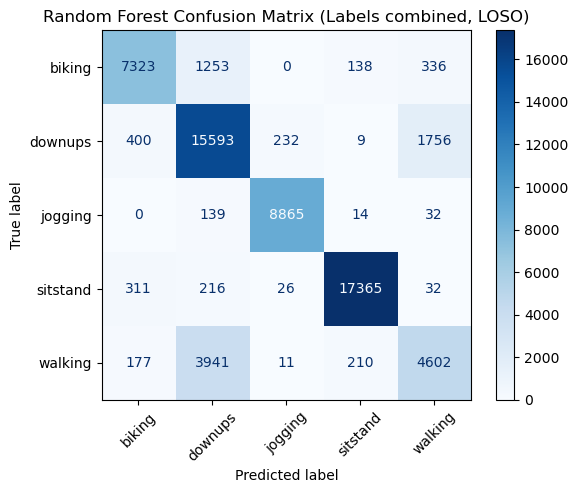

In [4]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



rf_params = {
    'n_estimators': 150,
    'max_depth': 10,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'random_state': 28
}

results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_comb[features_comb['participant'] != pid]
    test_df = features_comb[features_comb['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'participant': pid, 'accuracy': acc})
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO Accuracy (sitstand combined): {mean_acc:.3f}")

# Confusion matrix
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix (Labels combined, LOSO)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      biking       0.87      0.87      0.87       905
     downups       0.78      0.84      0.81      1790
     jogging       1.00      0.99      0.99       905
    sitstand       0.99      0.96      0.98      1795
     walking       0.67      0.61      0.64       886

    accuracy                           0.87      6281
   macro avg       0.86      0.85      0.86      6281
weighted avg       0.87      0.87      0.87      6281



#### SVM grouped labels


SVM Participant 1 - Accuracy: 0.888
SVM Participant 10 - Accuracy: 0.863
SVM Participant 2 - Accuracy: 0.886
SVM Participant 3 - Accuracy: 0.870
SVM Participant 4 - Accuracy: 0.850
SVM Participant 5 - Accuracy: 0.848
SVM Participant 6 - Accuracy: 0.910
SVM Participant 7 - Accuracy: 0.914
SVM Participant 8 - Accuracy: 0.882
SVM Participant 9 - Accuracy: 0.866

Mean LOSO Accuracy (SVM, poly kernel): 0.878


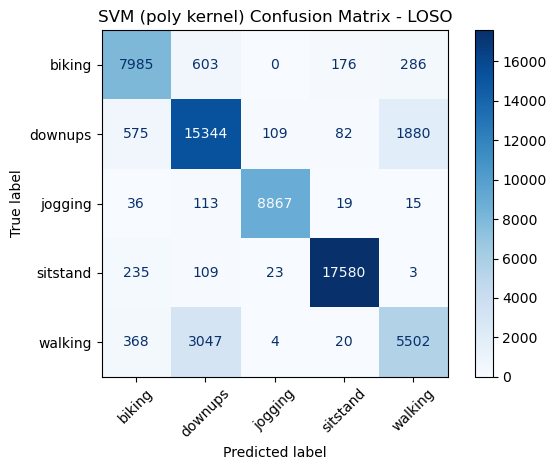

              precision    recall  f1-score   support

      biking       0.87      0.88      0.88      9050
     downups       0.80      0.85      0.82     17990
     jogging       0.98      0.98      0.98      9050
    sitstand       0.98      0.98      0.98     17950
     walking       0.72      0.62      0.66      8941

    accuracy                           0.88     62981
   macro avg       0.87      0.86      0.87     62981
weighted avg       0.88      0.88      0.88     62981



In [3]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

svm_results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    # Split data
    train_df = features_comb[features_comb['participant'] != pid]
    test_df = features_comb[features_comb['participant'] == pid]
    
    # Features and labels
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    # Feature count for gamma
    n_features = X_train.shape[1]

    # Train SVM classifier (polynomial kernel)
    svm_clf = SVC(kernel='poly', C=0.1, gamma=1/n_features, degree=2, random_state=42)
    svm_clf.fit(X_train, y_train)
    
    # Predict
    y_pred = svm_clf.predict(X_test)
    
    # Save results
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    svm_results.append({'participant': pid, 'accuracy': acc, 'report': report})

    print(f"SVM Participant {pid} - Accuracy: {acc:.3f}")

# Mean LOSO Accuracy
mean_svm_acc = np.mean([r['accuracy'] for r in svm_results])
print(f"\nMean LOSO Accuracy (SVM, poly kernel): {mean_svm_acc:.3f}")

# Confusion Matrix
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM (poly kernel) Confusion Matrix - LOSO")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(classification_report(all_y_true, all_y_pred, target_names=class_names))

#### MLP grouped labels


Participant 1 - Accuracy: 0.788
Participant 10 - Accuracy: 0.649
Participant 2 - Accuracy: 0.701
Participant 3 - Accuracy: 0.699
Participant 4 - Accuracy: 0.700
Participant 5 - Accuracy: 0.708
Participant 6 - Accuracy: 0.723
Participant 7 - Accuracy: 0.730
Participant 8 - Accuracy: 0.781
Participant 9 - Accuracy: 0.750

Mean LOSO MLP Accuracy: 0.723


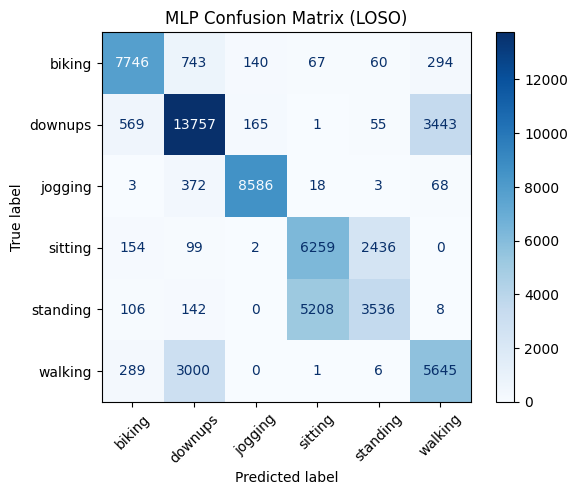

In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# LOSO cross-validation for MLP
results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_comb[features_comb['participant'] != pid]
    test_df = features_comb[features_comb['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    mlp = MLPClassifier(hidden_layer_sizes=(20, 20), solver='sgd', activation='tanh',
                        alpha=0.001, momentum=0.95, max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'participant': pid, 'accuracy': acc})
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO MLP Accuracy: {mean_acc:.3f}")

# Confusion matrix for all predictions
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("MLP Confusion Matrix (LOSO)")
plt.xticks(rotation=45)
plt.show()